Оптимальные параметры θ: [ 0.58415119  5.73137863 -8.51656823]
MSE на обучающей выборке: 0.7995022601021539
MSE на тестовой выборке: 4.153767859139606
Количество эпох: 1000


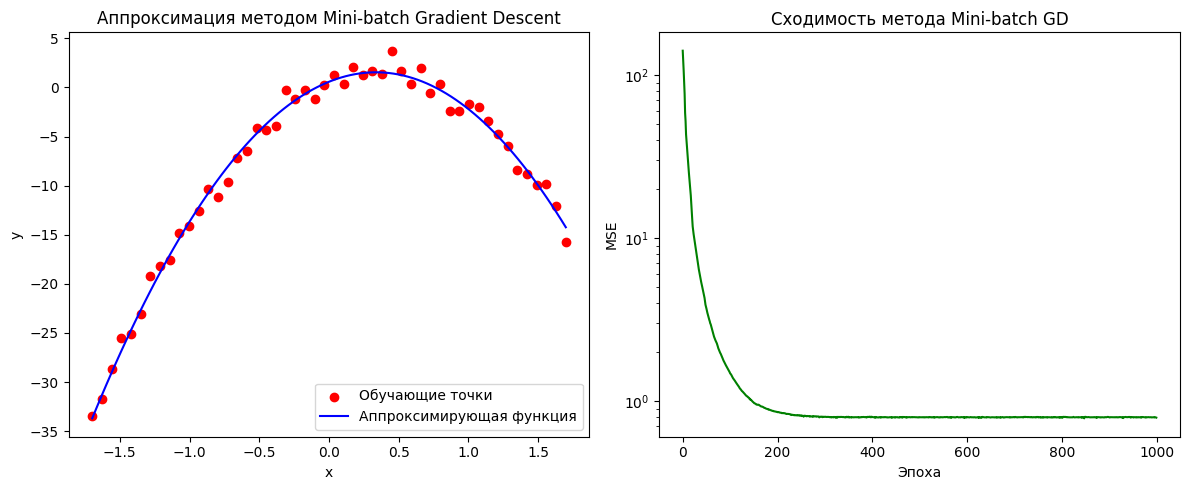

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Генерация обучающей выборки
def generate_train_data(n_samples=50):
    np.random.seed(42)
    x = np.linspace(-5, 5, n_samples)
    theta_true = [1.0, 2.0, -1.0]  # Истинные параметры
    y = theta_true[0] + theta_true[1] * x + theta_true[2] * x**2 + np.random.normal(0, 1, n_samples)
    return x, y, theta_true

def generate_test_data(n_samples=10):
    np.random.seed(42)
    x = np.linspace(-5, 5, n_samples)
    theta_true = [1.0, 2.0, -1.0]  # Истинные параметры
    y = theta_true[0] + theta_true[1] * x + theta_true[2] * x**2  # Без шума
    return x, y

# Нормализация данных
def normalize_data(x):
    return (x - np.mean(x)) / np.std(x)

# Квадратичная модель
def predict(theta, x):
    return theta[0] + theta[1] * x + theta[2] * x**2

# Функция потерь (MSE)
def compute_mse(theta, x, y):
    y_pred = predict(theta, x)
    return np.mean((y_pred - y)**2)

# Градиент для всей выборки
def compute_batch_gradient(theta, x, y):
    errors = predict(theta, x) - y
    grad_0 = np.mean(errors)
    grad_1 = np.mean(errors * x)
    grad_2 = np.mean(errors * x**2)
    return np.array([grad_0, grad_1, grad_2])

# Реализация Mini-batch Gradient Descent
def mini_batch_gradient_descent(x, y, theta_init, learning_rate=0.01,
                               batch_size=32, max_epochs=1000, tolerance=1e-6):
    n_samples = len(x)
    theta = theta_init.copy()
    loss_history = []

    for epoch in range(max_epochs):
        prev_theta = theta.copy()

        # Перемешивание данных
        indices = np.random.permutation(n_samples)
        x_shuffled = x[indices]
        y_shuffled = y[indices]

        epoch_loss = 0

        # Обработка мини-батчей
        for i in range(0, n_samples, batch_size):
            end_idx = min(i + batch_size, n_samples)
            x_batch = x_shuffled[i:end_idx]
            y_batch = y_shuffled[i:end_idx]

            # Градиент на мини-батче
            gradient = compute_batch_gradient(theta, x_batch, y_batch)

            # Обновление параметров
            theta -= learning_rate * gradient

            # Потеря на батче
            batch_loss = compute_mse(theta, x_batch, y_batch)
            epoch_loss += batch_loss * len(x_batch)

        # Средняя потеря за эпоху
        epoch_loss /= n_samples
        loss_history.append(epoch_loss)

        # Проверка сходимости
        if np.linalg.norm(theta - prev_theta) < tolerance:
            print(f"Mini-batch GD: Сходимость на эпохе {epoch}")
            break

    return theta, loss_history

# Построение графиков
def plot_results(x_train, y_train, theta, loss_history):
    plt.figure(figsize=(12, 5))

    # Аппроксимирующая функция
    plt.subplot(1, 2, 1)
    plt.scatter(x_train, y_train, color='red', label='Обучающие точки')
    x_curve = np.linspace(min(x_train), max(x_train), 100)
    y_curve = predict(theta, x_curve)
    plt.plot(x_curve, y_curve, color='blue', label='Аппроксимирующая функция')

    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.title('Аппроксимация методом Mini-batch Gradient Descent')

    # График сходимости
    plt.subplot(1, 2, 2)
    plt.plot(loss_history, color='green')
    plt.xlabel('Эпоха')
    plt.ylabel('MSE')
    plt.title('Сходимость метода Mini-batch GD')
    plt.yscale('log')

    plt.tight_layout()
    plt.show()

# Основная функция
def main():
    # Генерация и нормализация данных
    x_train_raw, y_train_raw, theta_true = generate_train_data(n_samples=50)
    x_train = normalize_data(x_train_raw)

    # Генерация тестовой выборки
    x_test_raw, y_test_raw = generate_test_data(n_samples=10)
    x_test = normalize_data(x_test_raw)

    # Начальные параметры
    theta_init = np.array([0.0, 0.0, 0.0])

    # Обучение методом Mini-batch GD
    theta_opt, loss_history = mini_batch_gradient_descent(
        x_train, y_train_raw, theta_init,
        learning_rate=0.01, batch_size=16, max_epochs=1000
    )

    # Вывод результатов
    mse_train = compute_mse(theta_opt, x_train, y_train_raw)
    mse_test = compute_mse(theta_opt, x_test, y_test_raw)

    print(f"Оптимальные параметры θ: {theta_opt}")
    print(f"MSE на обучающей выборке: {mse_train}")
    print(f"MSE на тестовой выборке: {mse_test}")
    print(f"Количество эпох: {len(loss_history)}")

    # Построение графиков
    plot_results(x_train, y_train_raw, theta_opt, loss_history)

if __name__ == "__main__":
    main()

Оптимальные параметры θ: [ 0.58200483  5.7193854  -8.48313354]
MSE на обучающей выборке: 0.7975946007119369
MSE на тестовой выборке: 4.336336841737863
Количество эпох: 2000


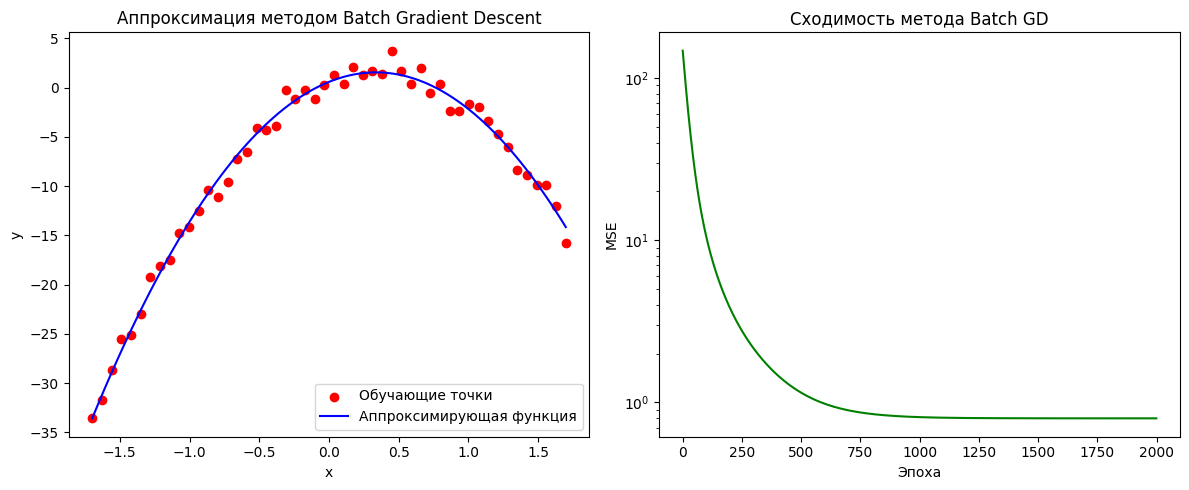

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Генерация обучающей выборки
def generate_train_data(n_samples=50):
    np.random.seed(42)
    x = np.linspace(-5, 5, n_samples)
    theta_true = [1.0, 2.0, -1.0]  # Истинные параметры
    y = theta_true[0] + theta_true[1] * x + theta_true[2] * x**2 + np.random.normal(0, 1, n_samples)
    return x, y, theta_true

def generate_test_data(n_samples=10):
    np.random.seed(42)
    x = np.linspace(-5, 5, n_samples)
    theta_true = [1.0, 2.0, -1.0]  # Истинные параметры
    y = theta_true[0] + theta_true[1] * x + theta_true[2] * x**2  # Без шума
    return x, y

# Нормализация данных
def normalize_data(x):
    return (x - np.mean(x)) / np.std(x)

# Квадратичная модель
def predict(theta, x):
    return theta[0] + theta[1] * x + theta[2] * x**2

# Функция потерь (MSE)
def compute_mse(theta, x, y):
    y_pred = predict(theta, x)
    return np.mean((y_pred - y)**2)

# Градиент для всей выборки
def compute_batch_gradient(theta, x, y):
    errors = predict(theta, x) - y
    grad_0 = np.mean(errors)
    grad_1 = np.mean(errors * x)
    grad_2 = np.mean(errors * x**2)
    return np.array([grad_0, grad_1, grad_2])

# Реализация Batch Gradient Descent
def batch_gradient_descent(x, y, theta_init, learning_rate=0.01,
                          max_epochs=1000, tolerance=1e-6):
    theta = theta_init.copy()
    loss_history = []

    for epoch in range(max_epochs):
        prev_theta = theta.copy()

        # Вычисление градиента для всей выборки
        gradient = compute_batch_gradient(theta, x, y)

        # Обновление параметров
        theta -= learning_rate * gradient

        # Вычисление MSE
        mse = compute_mse(theta, x, y)
        loss_history.append(mse)

        # Проверка сходимости
        if np.linalg.norm(theta - prev_theta) < tolerance:
            print(f"Batch GD: Сходимость на эпохе {epoch}")
            break

    return theta, loss_history

# Построение графиков
def plot_results(x_train, y_train, theta, loss_history):
    plt.figure(figsize=(12, 5))

    # Аппроксимирующая функция
    plt.subplot(1, 2, 1)
    plt.scatter(x_train, y_train, color='red', label='Обучающие точки')
    x_curve = np.linspace(min(x_train), max(x_train), 100)
    y_curve = predict(theta, x_curve)
    plt.plot(x_curve, y_curve, color='blue', label='Аппроксимирующая функция')

    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.title('Аппроксимация методом Batch Gradient Descent')

    # График сходимости
    plt.subplot(1, 2, 2)
    plt.plot(loss_history, color='green')
    plt.xlabel('Эпоха')
    plt.ylabel('MSE')
    plt.title('Сходимость метода Batch GD')
    plt.yscale('log')

    plt.tight_layout()
    plt.show()

# Основная функция
def main():
    # Генерация и нормализация данных
    x_train_raw, y_train_raw, theta_true = generate_train_data(n_samples=50)
    x_train = normalize_data(x_train_raw)

    # Генерация тестовой выборки
    x_test_raw, y_test_raw = generate_test_data(n_samples=10)
    x_test = normalize_data(x_test_raw)

    # Начальные параметры
    theta_init = np.array([0.0, 0.0, 0.0])

    # Обучение методом Batch GD
    theta_opt, loss_history = batch_gradient_descent(
        x_train, y_train_raw, theta_init,
        learning_rate=0.01, max_epochs=2000
    )

    # Вывод результатов
    mse_train = compute_mse(theta_opt, x_train, y_train_raw)
    mse_test = compute_mse(theta_opt, x_test, y_test_raw)

    print(f"Оптимальные параметры θ: {theta_opt}")
    print(f"MSE на обучающей выборке: {mse_train}")
    print(f"MSE на тестовой выборке: {mse_test}")
    print(f"Количество эпох: {len(loss_history)}")

    # Построение графиков
    plot_results(x_train, y_train_raw, theta_opt, loss_history)

if __name__ == "__main__":
    main()